<span style="font-size:36px">eCommerce Customer Segmentation and Behavioral Analytics</span>



## 🧩 eCommerce Customer Segmentation and Behavioral Analytics

This summary focuses exclusively on the final, descriptive analytics approach, detailing its structure and aims.

***

### 🔴 Problem Statement

* **Lack of Granular Insight:** Generic demographic analysis is insufficient for obtaining actionable data and understanding complex customer behaviors in the eCommerce sector.
* **Marketing Inefficiency:** Without distinct, behavior-based customer profiles, targeted marketing and customer retention efforts remain broad and fail to achieve optimal resource allocation.
* **Data Utilization Gap:** Essential patterns within transactional data, related to customer value and satisfaction, are concealed when analysis relies solely on simple aggregate metrics.

***

### ✅ Proposed Solution

* **Unsupervised Learning Implementation:** A **K-Means clustering** algorithm was adopted to perform behavioral segmentation, which groups customers based on their spending, engagement, and satisfaction metrics.
* **Persona Discovery Engine:** Development of a model that mathematically derives distinct customer profiles and links them to business logic.
* **Interactive Deployment:** Operationalizing the framework via a **Streamlit web application** for real-time classification and visualization of new customer profiles. 

[Image of customer segmentation dashboard]


***

### 🎯 Aims

* To establish a precise, data-driven framework for **customer profiling** that supersedes static demographic analysis.
* To discover and characterize hidden behavioral patterns that define high-value, loyal, and at-risk segments.
* To equip stakeholders with a tool for **real-time resource allocation** by facilitating personalized marketing interventions.

***

### 📋 Objectives

* **Algorithmic Modeling:** Training and optimizing a K-Means clustering model ($k=4$) to segment users based on key behavioral features (e.g., total expenditure, discount usage, satisfaction).
* **Cluster Interpretation:** Analyzing cluster centroids to define four distinct, actionable personas: *The Big Spender*, *The Loyal Regular*, *The Thrifty Browser*, and *The At-Risk Customer*.
* **System Deployment:** Creating a dashboard interface that visualizes customer positioning relative to cluster averages and recommends specific business actions for immediate implementation.

<span style="font-size:24px">Step 1: Enhanced Data Preparation for Neural Networks</span>

In [1]:





# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
df = pd.read_csv('ecommerce_customer_behavior_dataset_v2.csv')
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
df.head()


Dataset shape: (17049, 18)

First few rows:


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


<span style="font-size:24px">Step 2. Data Exploration and Preprocessing
</span>


Selected Features:
['Total_Amount', 'Quantity', 'Discount_Amount', 'Session_Duration_Minutes', 'Pages_Viewed', 'Customer_Rating']

Missing values:
Total_Amount                0
Quantity                    0
Discount_Amount             0
Session_Duration_Minutes    0
Pages_Viewed                0
Customer_Rating             0
dtype: int64

Dataset Statistics:


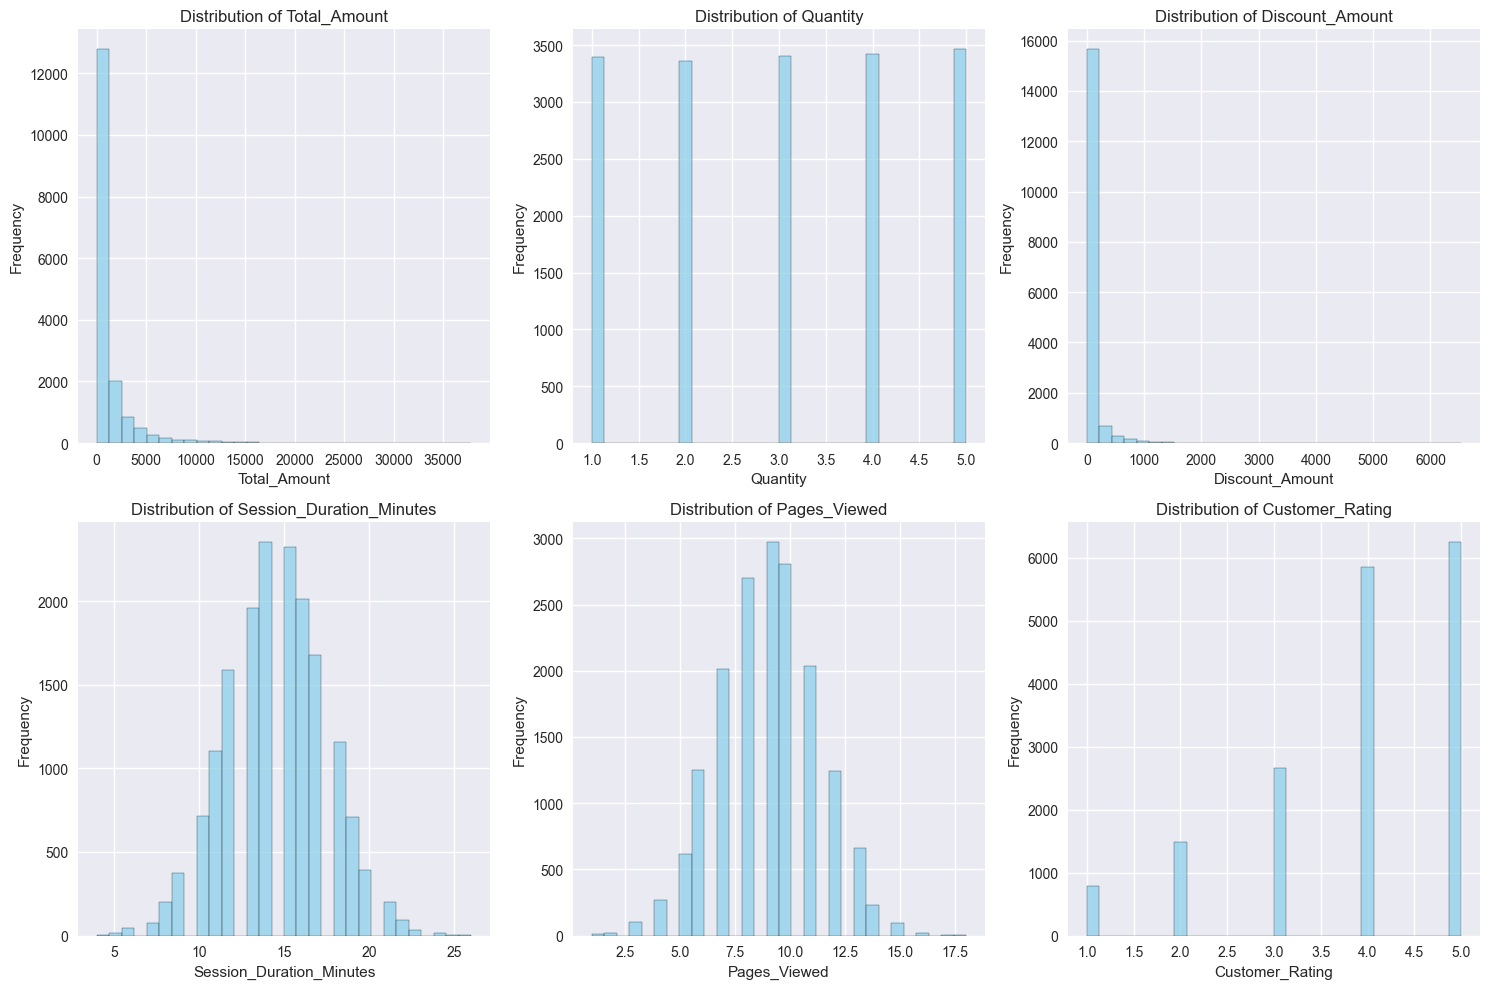

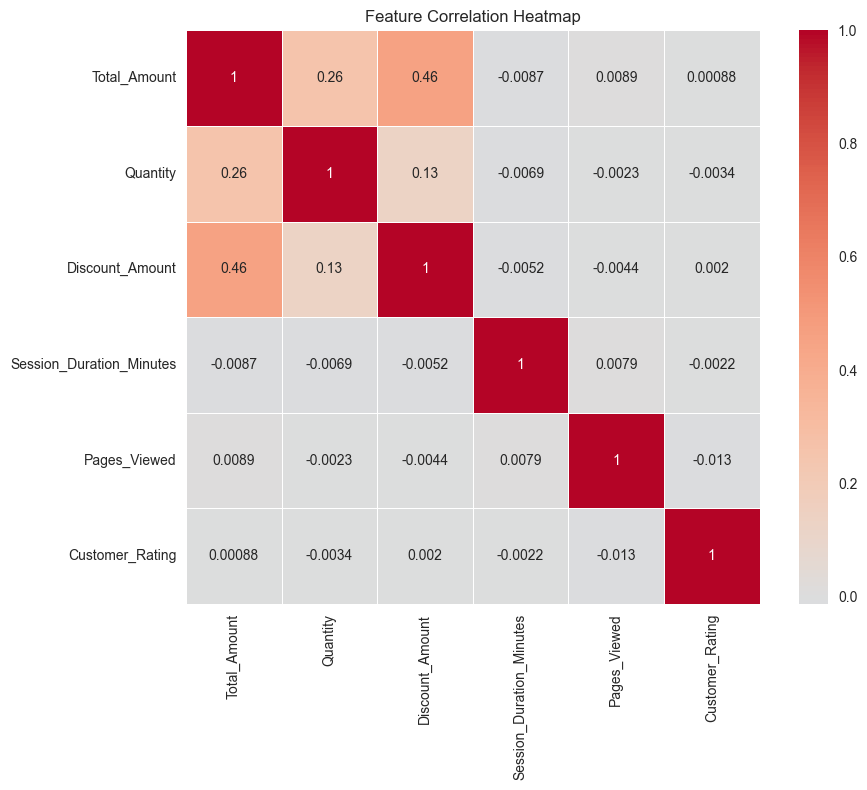

Feature scaling completed:
Original shape: (17049, 6)
Scaled shape: (17049, 6)


In [2]:
# Select features for segmentation
features = [
    'Total_Amount', 
    'Quantity', 
    'Discount_Amount', 
    'Session_Duration_Minutes', 
    'Pages_Viewed', 
    'Customer_Rating'
]

print("Selected Features:")
print(features)

# Check for missing values
print("\nMissing values:")
print(df[features].isnull().sum())

# Basic statistics
print("\nDataset Statistics:")
df[features].describe()

# %%
# Visualize feature distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(features):
    axes[i].hist(df[feature], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# %%
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# %%
# Preprocessing: Standardize features
X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed:")
print(f"Original shape: {X.shape}")
print(f"Scaled shape: {X_scaled.shape}")


<span style="font-size:24px">Step 3. K-Means Clustering</span>


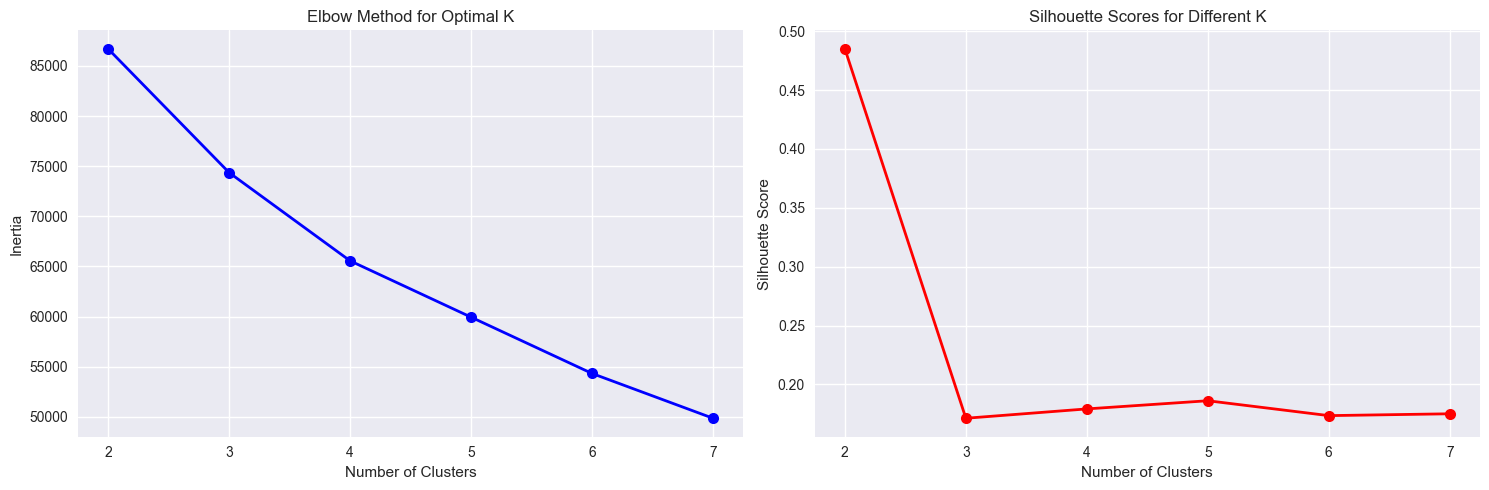

K-Means Clustering Results:
Number of clusters: 4
Silhouette Score: 0.179
Calinski-Harabasz Score: 3183.209
Davies-Bouldin Score: 1.598

K-Means Cluster Identification:
Cluster 0: 💎 The Big Spender
Cluster 1: 📉 The At-Risk Customer
Cluster 2: 🛒 The Thrifty Browser
Cluster 3: 💖 The Loyal Regular


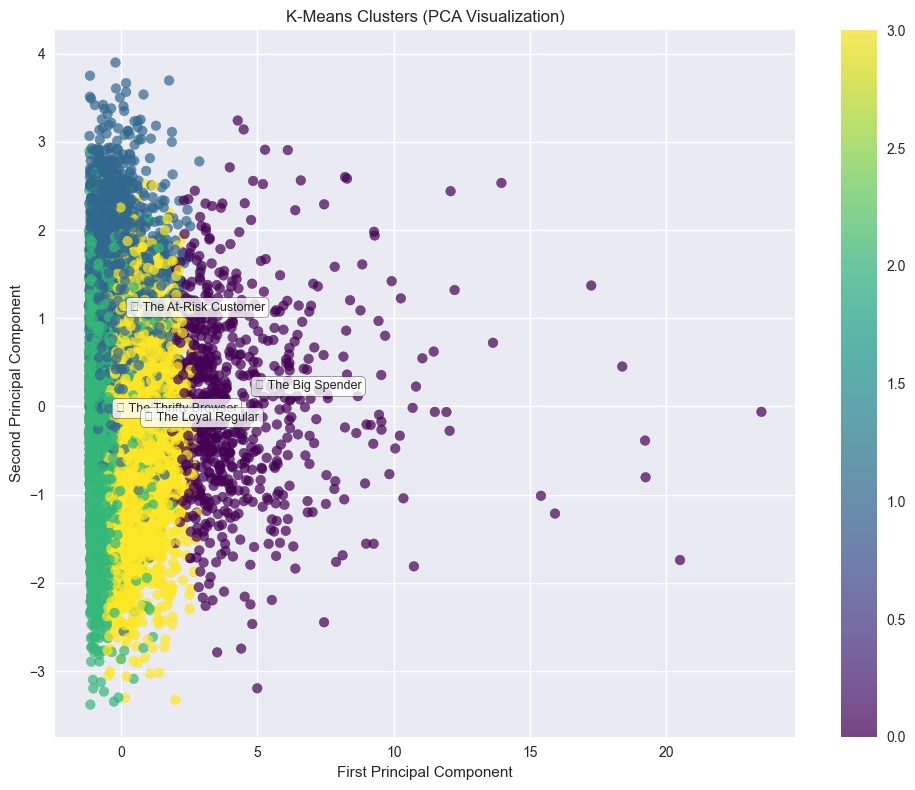

In [3]:
# Determine optimal number of clusters using elbow method
inertia = []
silhouette_scores = []
k_range = range(2, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

# Plot elbow curve and silhouette scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
ax1.plot(k_range, inertia, 'bo-', markersize=8, linewidth=2)
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal K')
ax1.grid(True)

# Silhouette scores
ax2.plot(k_range, silhouette_scores, 'ro-', markersize=8, linewidth=2)
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Scores for Different K')
ax2.grid(True)

plt.tight_layout()
plt.show()

# %%
# Train final K-Means model with 4 clusters
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['KMeans_Cluster'] = kmeans_labels

# Calculate cluster metrics
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(X_scaled, kmeans_labels)
kmeans_davies = davies_bouldin_score(X_scaled, kmeans_labels)

print("K-Means Clustering Results:")
print(f"Number of clusters: {k}")
print(f"Silhouette Score: {kmeans_silhouette:.3f}")
print(f"Calinski-Harabasz Score: {kmeans_calinski:.3f}")
print(f"Davies-Bouldin Score: {kmeans_davies:.3f}")

# %%
# Analyze K-Means clusters
kmeans_means = df.groupby('KMeans_Cluster')[features].mean()

# Create cluster mapping for K-Means
kmeans_cluster_mapping = {}

# Find "The Big Spender" (Max Total Amount)
big_spender_idx = kmeans_means['Total_Amount'].idxmax()
kmeans_cluster_mapping[big_spender_idx] = {
    'name': '💎 The Big Spender',
    'desc': 'High spender, buys in bulk. Uses discounts.',
    'action': 'Assign VIP account manager. Offer exclusive presales.'
}

# Find "The At-Risk Customer" (Lowest Rating)
at_risk_idx = kmeans_means['Customer_Rating'].idxmin()
kmeans_cluster_mapping[at_risk_idx] = {
    'name': '📉 The At-Risk Customer',
    'desc': 'Low satisfaction, low spending. Likely to churn.',
    'action': 'Send personalized apology or feedback survey.'
}

# Find "The Loyal Regular" (High Quantity, High Rating, but not the Whale)
remaining = [c for c in range(k) if c not in [big_spender_idx, at_risk_idx]]
loyal_idx = kmeans_means.loc[remaining, 'Quantity'].idxmax()
kmeans_cluster_mapping[loyal_idx] = {
    'name': '💖 The Loyal Regular',
    'desc': 'Happy, frequent buyer with moderate spend.',
    'action': 'Enroll in Loyalty Program. Offer "Refer a Friend" bonus.'
}

# The last one is "The Thrifty Browser"
thrifty_idx = [c for c in range(k) if c not in kmeans_cluster_mapping][0]
kmeans_cluster_mapping[thrifty_idx] = {
    'name': '🛒 The Thrifty Browser',
    'desc': 'Browses often, buys little, but is generally happy.',
    'action': 'Nudge with "Free Shipping" or low-barrier offers.'
}

print("\nK-Means Cluster Identification:")
for i in range(k):
    print(f"Cluster {i}: {kmeans_cluster_mapping[i]['name']}")

# %%
# Visualize K-Means clusters using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('K-Means Clusters (PCA Visualization)')

# Add cluster names to the plot
for cluster_id in range(k):
    cluster_points = X_pca[kmeans_labels == cluster_id]
    center = cluster_points.mean(axis=0)
    plt.annotate(kmeans_cluster_mapping[cluster_id]['name'], 
                center, xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                fontsize=9)

plt.tight_layout()
plt.show()

<span style="font-size:24px">Step 4. Neural Network Approach (Autoencoder + Clustering)</span>


Training Neural Network Autoencoder...
Neural Network Clustering Results:
Silhouette Score: 0.097
Calinski-Harabasz Score: 2264.653
Davies-Bouldin Score: 2.459

Neural Network Cluster Identification:
Cluster 0: 🛒 The Thrifty Browser
Cluster 1: 💎 The Big Spender
Cluster 2: 📉 The At-Risk Customer
Cluster 3: 💖 The Loyal Regular


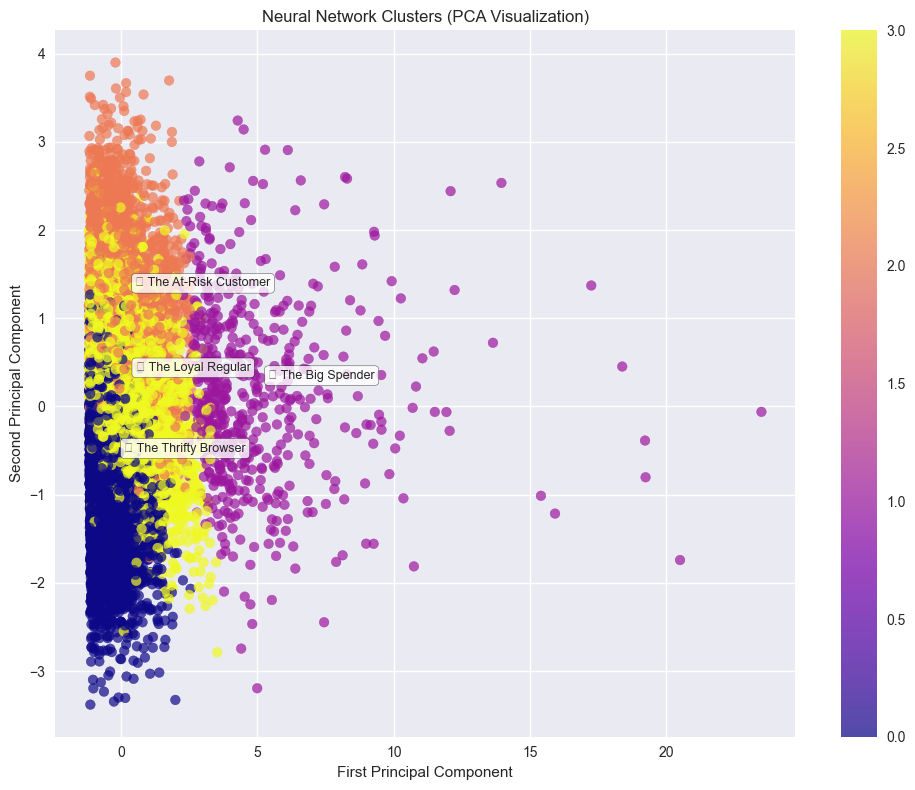

In [4]:

    
from sklearn.neural_network import MLPRegressor
from sklearn.base import TransformerMixin, ClusterMixin
from sklearn.cluster import KMeans
import numpy as np

class AutoencoderCluster(TransformerMixin, ClusterMixin):
    def __init__(self, hidden_dim=3, n_clusters=4, random_state=42):
        self.hidden_dim = hidden_dim
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.autoencoder = None
        self.kmeans = None
        self.labels_ = None
        
    def fit(self, X, y=None):
        # Create autoencoder
        self.autoencoder = MLPRegressor(
            hidden_layer_sizes=(self.hidden_dim,), # Hidden layer size
            activation='relu',
            random_state=self.random_state,
            max_iter=1000
        )
        
        # Train autoencoder to reconstruct input (X -> X)
        self.autoencoder.fit(X, X)
        
        # Get encoded features (Standard Forward Pass: Input @ Weights + Bias)
        # coefs_[0] shape is (n_features, hidden_dim)
        encoded_features = X @ self.autoencoder.coefs_[0] + self.autoencoder.intercepts_[0]
        encoded_features = np.maximum(0, encoded_features)  # ReLU activation
        
        # Apply K-Means on encoded features
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        self.labels_ = self.kmeans.fit_predict(encoded_features)
        
        return self
    
    def fit_predict(self, X, y=None):
        self.fit(X, y)
        return self.labels_
    
    def predict(self, X):
        # Transform new data using the trained autoencoder weights
        encoded_features = X @ self.autoencoder.coefs_[0] + self.autoencoder.intercepts_[0]
        encoded_features = np.maximum(0, encoded_features)
        return self.kmeans.predict(encoded_features)


print("Training Neural Network Autoencoder...")
nn_model = AutoencoderCluster(hidden_dim=3, n_clusters=4, random_state=42)
nn_labels = nn_model.fit_predict(X_scaled) 


# df['NN_Cluster'] = nn_labels
df['NN_Cluster'] = nn_labels

# Calculate metrics for NN approach
nn_silhouette = silhouette_score(X_scaled, nn_labels)
nn_calinski = calinski_harabasz_score(X_scaled, nn_labels)
nn_davies = davies_bouldin_score(X_scaled, nn_labels)

print("Neural Network Clustering Results:")
print(f"Silhouette Score: {nn_silhouette:.3f}")
print(f"Calinski-Harabasz Score: {nn_calinski:.3f}")
print(f"Davies-Bouldin Score: {nn_davies:.3f}")

# %%
# Analyze Neural Network clusters
nn_means = df.groupby('NN_Cluster')[features].mean()

# Create cluster mapping for Neural Network
nn_cluster_mapping = {}

# Use similar logic as K-Means for consistency
big_spender_idx = nn_means['Total_Amount'].idxmax()
nn_cluster_mapping[big_spender_idx] = {
    'name': '💎 The Big Spender',
    'desc': 'High spender, buys in bulk. Uses discounts.',
    'action': 'Assign VIP account manager. Offer exclusive presales.'
}

at_risk_idx = nn_means['Customer_Rating'].idxmin()
nn_cluster_mapping[at_risk_idx] = {
    'name': '📉 The At-Risk Customer',
    'desc': 'Low satisfaction, low spending. Likely to churn.',
    'action': 'Send personalized apology or feedback survey.'
}

remaining = [c for c in range(k) if c not in [big_spender_idx, at_risk_idx]]
loyal_idx = nn_means.loc[remaining, 'Quantity'].idxmax()
nn_cluster_mapping[loyal_idx] = {
    'name': '💖 The Loyal Regular',
    'desc': 'Happy, frequent buyer with moderate spend.',
    'action': 'Enroll in Loyalty Program. Offer "Refer a Friend" bonus.'
}

thrifty_idx = [c for c in range(k) if c not in nn_cluster_mapping][0]
nn_cluster_mapping[thrifty_idx] = {
    'name': '🛒 The Thrifty Browser',
    'desc': 'Browses often, buys little, but is generally happy.',
    'action': 'Nudge with "Free Shipping" or low-barrier offers.'
}

print("\nNeural Network Cluster Identification:")
for i in range(k):
    print(f"Cluster {i}: {nn_cluster_mapping[i]['name']}")

# %%
# Visualize Neural Network clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=nn_labels, cmap='plasma', alpha=0.7)
plt.colorbar(scatter)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Neural Network Clusters (PCA Visualization)')

# Add cluster names to the plot
for cluster_id in range(k):
    cluster_points = X_pca[nn_labels == cluster_id]
    if len(cluster_points) > 0:
        center = cluster_points.mean(axis=0)
        plt.annotate(nn_cluster_mapping[cluster_id]['name'], 
                    center, xytext=(10, 10), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                    fontsize=9)

plt.tight_layout()
plt.show()

<span style="font-size:24px">Step 5. Random Forest Feature Importance + Clustering</span>


Random Forest Classifier Results:
Accuracy on test set: 0.989

Feature Importance:
                    feature  importance
1                  Quantity    0.451915
5           Customer_Rating    0.358402
0              Total_Amount    0.089780
2           Discount_Amount    0.052131
3  Session_Duration_Minutes    0.043468
4              Pages_Viewed    0.004305


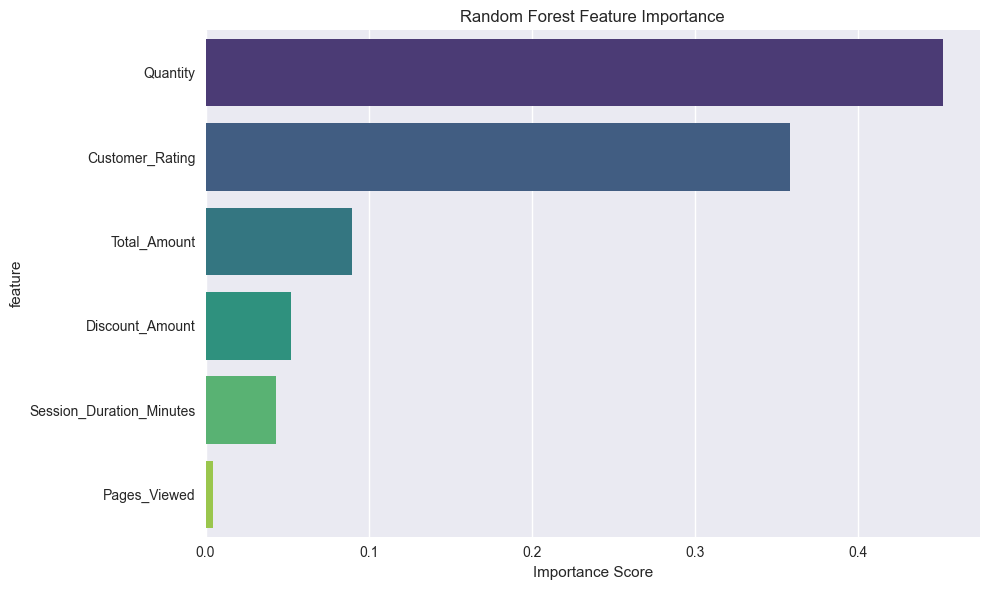

Random Forest Feature Selection Clustering Results:
Top features used: ['Total_Amount', 'Customer_Rating', 'Quantity']
Silhouette Score: 0.176
Calinski-Harabasz Score: 2919.952
Davies-Bouldin Score: 1.621

Random Forest Cluster Identification:
Cluster 0: 💎 The Big Spender
Cluster 1: 💖 The Loyal Regular
Cluster 2: 📉 The At-Risk Customer
Cluster 3: 🛒 The Thrifty Browser


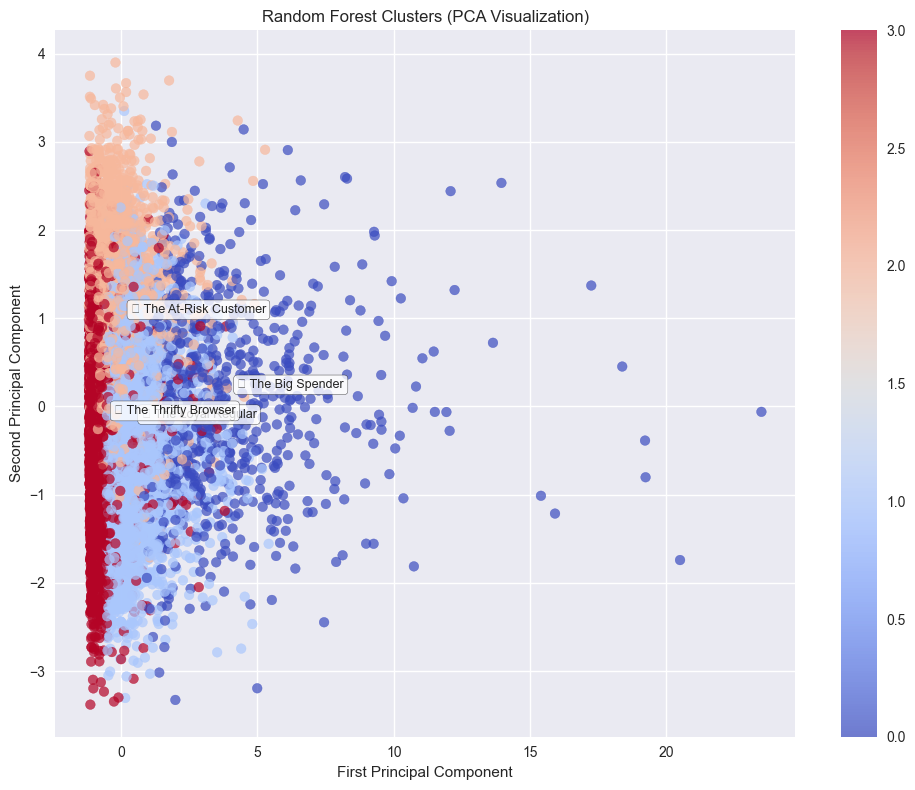

In [5]:
# First, let's use K-Means labels to train Random Forest and get feature importance
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, kmeans_labels, test_size=0.2, random_state=42, stratify=kmeans_labels
)

# Train Random Forest classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=5
)

rf_classifier.fit(X_train, y_train)
rf_accuracy = rf_classifier.score(X_test, y_test)

print("Random Forest Classifier Results:")
print(f"Accuracy on test set: {rf_accuracy:.3f}")

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# %%
# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# %%
# Use top features for clustering (alternative approach)
top_features_idx = np.argsort(rf_classifier.feature_importances_)[-3:]  # Top 3 features
X_rf_selected = X_scaled[:, top_features_idx]

# Apply K-Means on selected features
rf_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rf_labels = rf_kmeans.fit_predict(X_rf_selected)
df['RF_Cluster'] = rf_labels

# Calculate metrics for RF approach
rf_silhouette = silhouette_score(X_scaled, rf_labels)
rf_calinski = calinski_harabasz_score(X_scaled, rf_labels)
rf_davies = davies_bouldin_score(X_scaled, rf_labels)

print("Random Forest Feature Selection Clustering Results:")
print(f"Top features used: {[features[i] for i in top_features_idx]}")
print(f"Silhouette Score: {rf_silhouette:.3f}")
print(f"Calinski-Harabasz Score: {rf_calinski:.3f}")
print(f"Davies-Bouldin Score: {rf_davies:.3f}")

# %%
# Analyze Random Forest clusters
rf_means = df.groupby('RF_Cluster')[features].mean()

# Create cluster mapping for Random Forest
rf_cluster_mapping = {}

# Use similar logic as previous methods
big_spender_idx = rf_means['Total_Amount'].idxmax()
rf_cluster_mapping[big_spender_idx] = {
    'name': '💎 The Big Spender',
    'desc': 'High spender, buys in bulk. Uses discounts.',
    'action': 'Assign VIP account manager. Offer exclusive presales.'
}

at_risk_idx = rf_means['Customer_Rating'].idxmin()
rf_cluster_mapping[at_risk_idx] = {
    'name': '📉 The At-Risk Customer',
    'desc': 'Low satisfaction, low spending. Likely to churn.',
    'action': 'Send personalized apology or feedback survey.'
}

remaining = [c for c in range(k) if c not in [big_spender_idx, at_risk_idx]]
loyal_idx = rf_means.loc[remaining, 'Quantity'].idxmax()
rf_cluster_mapping[loyal_idx] = {
    'name': '💖 The Loyal Regular',
    'desc': 'Happy, frequent buyer with moderate spend.',
    'action': 'Enroll in Loyalty Program. Offer "Refer a Friend" bonus.'
}

thrifty_idx = [c for c in range(k) if c not in rf_cluster_mapping][0]
rf_cluster_mapping[thrifty_idx] = {
    'name': '🛒 The Thrifty Browser',
    'desc': 'Browses often, buys little, but is generally happy.',
    'action': 'Nudge with "Free Shipping" or low-barrier offers.'
}

print("\nRandom Forest Cluster Identification:")
for i in range(k):
    print(f"Cluster {i}: {rf_cluster_mapping[i]['name']}")

# %%
# Visualize Random Forest clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=rf_labels, cmap='coolwarm', alpha=0.7)
plt.colorbar(scatter)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Random Forest Clusters (PCA Visualization)')

# Add cluster names to the plot
for cluster_id in range(k):
    cluster_points = X_pca[rf_labels == cluster_id]
    if len(cluster_points) > 0:
        center = cluster_points.mean(axis=0)
        plt.annotate(rf_cluster_mapping[cluster_id]['name'], 
                    center, xytext=(10, 10), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                    fontsize=9)

plt.tight_layout()
plt.show()


<span style="font-size:24px">Step 6. Model Comparison and Evaluation</span>


Model Comparison:
            Model  Silhouette Score  Calinski-Harabasz Score  \
0         K-Means             0.179                 3183.209   
1  Neural Network             0.097                 2264.653   
2   Random Forest             0.176                 2919.952   

   Davies-Bouldin Score  
0                 1.598  
1                 2.459  
2                 1.621  


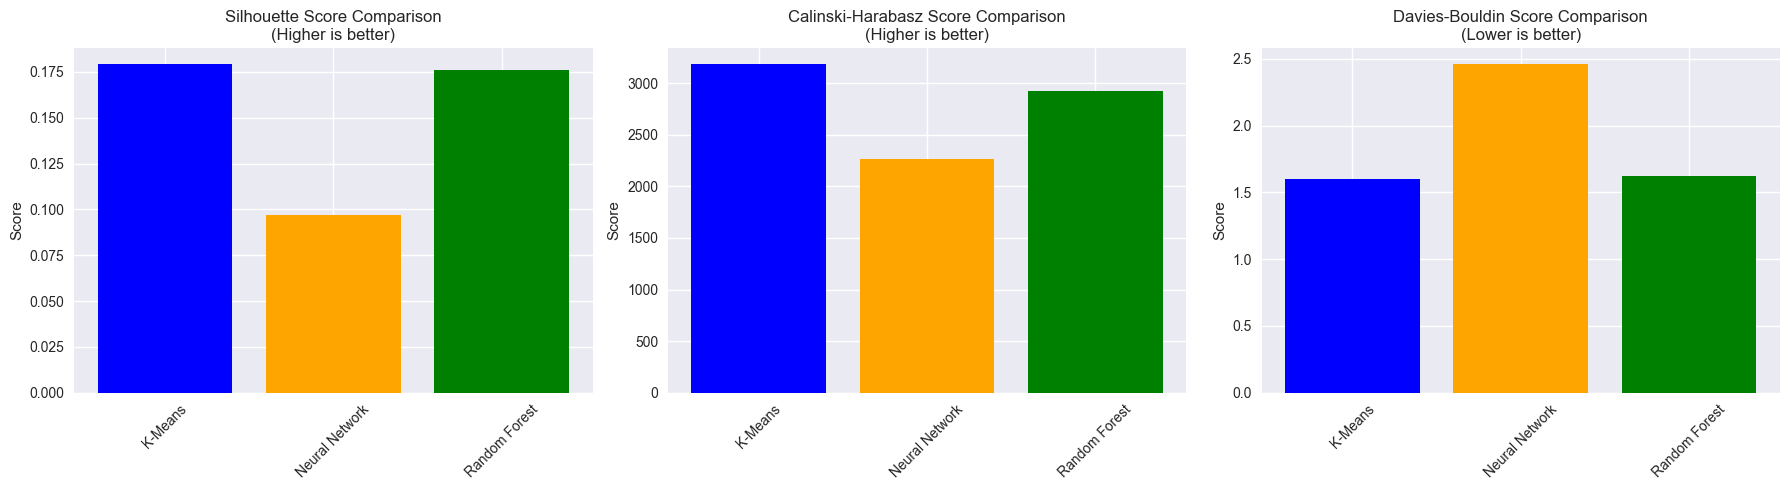

Cluster Distribution Comparison:
   K-Means  Neural Network  Random Forest
0      700            7351            778
1     3626             551           7289
2     6499            2679           3669
3     6224            6468           5313


<Figure size 1200x600 with 0 Axes>

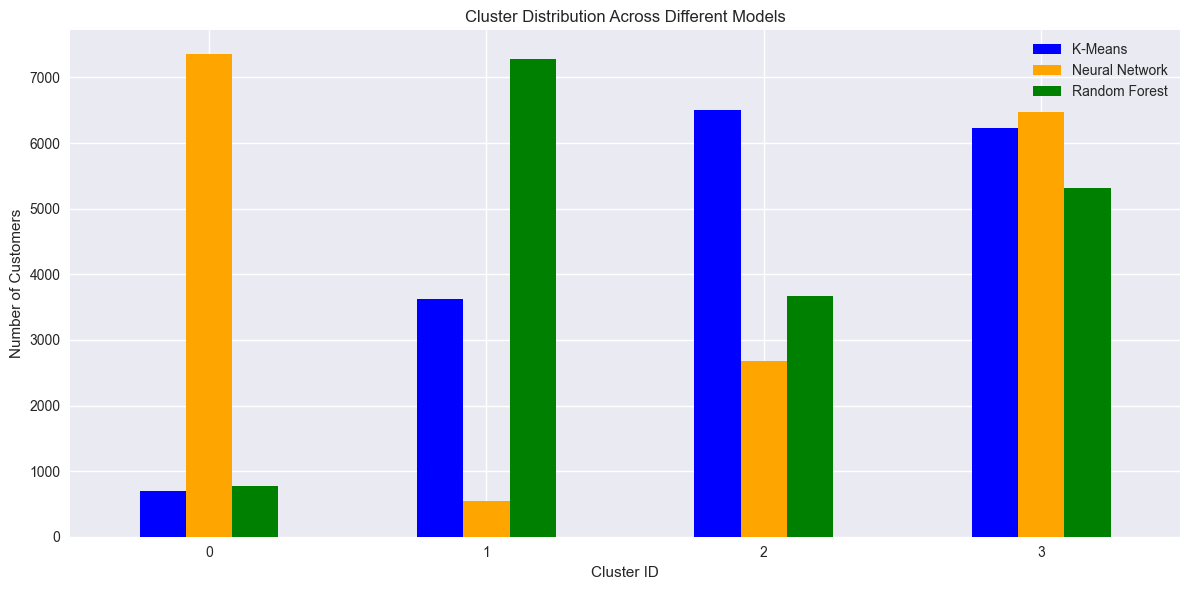

In [6]:
# Create comparison table
comparison_data = {
    'Model': ['K-Means', 'Neural Network', 'Random Forest'],
    'Silhouette Score': [kmeans_silhouette, nn_silhouette, rf_silhouette],
    'Calinski-Harabasz Score': [kmeans_calinski, nn_calinski, rf_calinski],
    'Davies-Bouldin Score': [kmeans_davies, nn_davies, rf_davies]
}

comparison_df = pd.DataFrame(comparison_data)
print("Model Comparison:")
print(comparison_df.round(3))

# %%
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Silhouette Score comparison
axes[0].bar(comparison_df['Model'], comparison_df['Silhouette Score'], color=['blue', 'orange', 'green'])
axes[0].set_title('Silhouette Score Comparison\n(Higher is better)')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)

# Calinski-Harabasz Score comparison
axes[1].bar(comparison_df['Model'], comparison_df['Calinski-Harabasz Score'], color=['blue', 'orange', 'green'])
axes[1].set_title('Calinski-Harabasz Score Comparison\n(Higher is better)')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=45)

# Davies-Bouldin Score comparison
axes[2].bar(comparison_df['Model'], comparison_df['Davies-Bouldin Score'], color=['blue', 'orange', 'green'])
axes[2].set_title('Davies-Bouldin Score Comparison\n(Lower is better)')
axes[2].set_ylabel('Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# %%
# Compare cluster distributions
cluster_distribution = pd.DataFrame({
    'K-Means': df['KMeans_Cluster'].value_counts().sort_index(),
    'Neural Network': df['NN_Cluster'].value_counts().sort_index(),
    'Random Forest': df['RF_Cluster'].value_counts().sort_index()
})

print("Cluster Distribution Comparison:")
print(cluster_distribution)

# %%
# Visualize cluster distributions
plt.figure(figsize=(12, 6))
cluster_distribution.plot(kind='bar', figsize=(12, 6), color=['blue', 'orange', 'green'])
plt.title('Cluster Distribution Across Different Models')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

<span style="font-size:24px">Step 7. Detailed Cluster Analysis </span>


In [7]:
# Function to display cluster profiles
def display_cluster_profiles(model_name, means, mapping):
    print(f"\n{model_name} Cluster Profiles:")
    print("="*50)
    
    for cluster_id in range(len(means)):
        profile = mapping[cluster_id]
        print(f"\n{profile['name']} (Cluster {cluster_id})")
        print(f"Description: {profile['desc']}")
        print(f"Recommended Action: {profile['action']}")
        print("\nAverage Features:")
        for feature in features:
            print(f"  {feature}: {means.loc[cluster_id, feature]:.2f}")
        print("-" * 30)

# Display profiles for each model
display_cluster_profiles("K-Means", kmeans_means, kmeans_cluster_mapping)
display_cluster_profiles("Neural Network", nn_means, nn_cluster_mapping)
display_cluster_profiles("Random Forest", rf_means, rf_cluster_mapping)


K-Means Cluster Profiles:

💎 The Big Spender (Cluster 0)
Description: High spender, buys in bulk. Uses discounts.
Recommended Action: Assign VIP account manager. Offer exclusive presales.

Average Features:
  Total_Amount: 9392.04
  Quantity: 4.03
  Discount_Amount: 778.27
  Session_Duration_Minutes: 14.65
  Pages_Viewed: 8.96
  Customer_Rating: 3.89
------------------------------

📉 The At-Risk Customer (Cluster 1)
Description: Low satisfaction, low spending. Likely to churn.
Recommended Action: Send personalized apology or feedback survey.

Average Features:
  Total_Amount: 909.81
  Quantity: 2.99
  Discount_Amount: 40.05
  Session_Duration_Minutes: 14.65
  Pages_Viewed: 9.03
  Customer_Rating: 2.19
------------------------------

🛒 The Thrifty Browser (Cluster 2)
Description: Browses often, buys little, but is generally happy.
Recommended Action: Nudge with "Free Shipping" or low-barrier offers.

Average Features:
  Total_Amount: 549.94
  Quantity: 1.73
  Discount_Amount: 26.78
  S

<span style="font-size:24px">Final Results</span>


All artifacts saved to 'segmentation_artifacts_comprehensive.joblib'

🎯 RECOMMENDATION: Based on Silhouette Score, the best model is K-Means

📊 SUMMARY:
• K-Means: Simple, interpretable, good baseline
• Neural Network: Can capture complex patterns, may overfit on small datasets
• Random Forest: Provides feature importance, robust to outliers

For most business applications, K-Means is recommended due to its simplicity and interpretability.


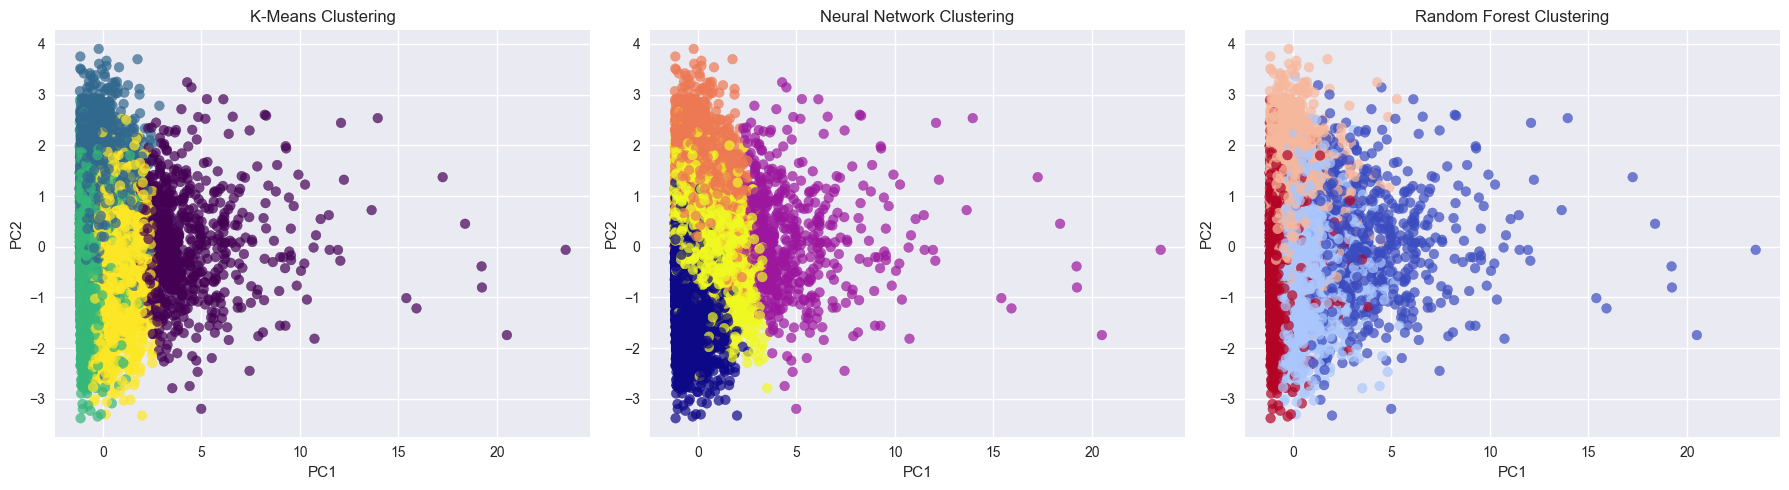

In [8]:
# Save all artifacts
artifacts = {
    'scaler': scaler,
    'kmeans_model': kmeans,
    'nn_model': nn_model,
    'rf_classifier': rf_classifier,
    'rf_kmeans': rf_kmeans,
    'features': features,
    'pca': pca,
    'kmeans_cluster_mapping': kmeans_cluster_mapping,
    'nn_cluster_mapping': nn_cluster_mapping,
    'rf_cluster_mapping': rf_cluster_mapping,
    'kmeans_means': kmeans_means,
    'nn_means': nn_means,
    'rf_means': rf_means,
    'comparison_df': comparison_df
}

joblib.dump(artifacts, 'segmentation_artifacts_comprehensive.joblib')
print("All artifacts saved to 'segmentation_artifacts_comprehensive.joblib'")

# %%
# Final recommendations
best_model = comparison_df.loc[comparison_df['Silhouette Score'].idxmax(), 'Model']
print(f"\n🎯 RECOMMENDATION: Based on Silhouette Score, the best model is {best_model}")

print("\n📊 SUMMARY:")
print(f"• K-Means: Simple, interpretable, good baseline")
print(f"• Neural Network: Can capture complex patterns, may overfit on small datasets")  
print(f"• Random Forest: Provides feature importance, robust to outliers")
print(f"\nFor most business applications, K-Means is recommended due to its simplicity and interpretability.")

# %%
# Create final visualization showing all three methods
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
axes[0].set_title('K-Means Clustering')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Neural Network
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=nn_labels, cmap='plasma', alpha=0.7)
axes[1].set_title('Neural Network Clustering')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# Random Forest
scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=rf_labels, cmap='coolwarm', alpha=0.7)
axes[2].set_title('Random Forest Clustering')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

<span style="font-size:24px">Final Optimized approach</span>


In [9]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix


from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline 



df['Is_Returning_Customer'] = df['Is_Returning_Customer'].astype(bool)
df['target'] = df['Is_Returning_Customer'].astype(int)

# 2. Basic Date FE
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['order_month'] = df['Date'].dt.month.fillna(0).astype(int)
df['order_dayofweek'] = df['Date'].dt.dayofweek.fillna(0).astype(int)

# Initial features
initial_features = [
    'Age','Gender','City','Product_Category','Unit_Price','Quantity','Discount_Amount','Total_Amount',
    'Payment_Method','Device_Type','Session_Duration_Minutes','Pages_Viewed','Delivery_Time_Days',
    'order_month','order_dayofweek', 'Customer_Rating'
]

X = df[initial_features].copy()
y = df['target']

# 3. Split (Critical: Split BEFORE SMOTE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Copies to avoid warnings
X_train = X_train.copy()
X_test = X_test.copy()

print(f"Original Train Class Distribution: {np.bincount(y_train)}")

#Fe
# --- A. City Reduction ---
top_cities = X_train['City'].value_counts().nlargest(10).index
X_train['City_small'] = np.where(X_train['City'].isin(top_cities), X_train['City'], 'Other')
X_test['City_small'] = np.where(X_test['City'].isin(top_cities), X_test['City'], 'Other')

# --- B. Clustering ---
cluster_cols = ['Age','Unit_Price','Quantity','Total_Amount','Session_Duration_Minutes','Pages_Viewed','Delivery_Time_Days']

cluster_prep = SimpleImputer(strategy='median')
# Note: Scaling happens inside the main pipeline, but for KMeans we need a temporary scaler
# We'll just use the raw values for simplicity or a quick separate scaler as before
from sklearn.pipeline import make_pipeline as make_sklearn_pipeline
cluster_pipeline = make_sklearn_pipeline(SimpleImputer(strategy='median'), StandardScaler())

X_train_clus_scaled = cluster_pipeline.fit_transform(X_train[cluster_cols])
X_test_clus_scaled = cluster_pipeline.transform(X_test[cluster_cols])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=5)
kmeans.fit(X_train_clus_scaled)

X_train['cust_cluster'] = kmeans.predict(X_train_clus_scaled)
X_test['cust_cluster'] = kmeans.predict(X_test_clus_scaled)

#smote pipeline

numeric_features = ['Age','Unit_Price','Quantity','Discount_Amount','Total_Amount',
                    'Session_Duration_Minutes','Pages_Viewed','Delivery_Time_Days',
                    'order_month','order_dayofweek','cust_cluster', 'Customer_Rating']

categorical_features = ['Gender','City_small','Product_Category','Payment_Method','Device_Type']

numeric_transformer = make_sklearn_pipeline(SimpleImputer(strategy='median'), StandardScaler())
categorical_transformer = make_sklearn_pipeline(
    SimpleImputer(strategy='constant', fill_value='missing'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False) # sparse_output=False helps SMOTE
)

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# THE SMOTE PIPELINE
# 1. Preprocess (Scale/Encode) -> 2. SMOTE (Balance Data) -> 3. Random Forest (Train)
model_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)), 
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

print("Training with SMOTE...")
model_pipeline.fit(X_train, y_train)

# Evaluate
y_pred = model_pipeline.predict(X_test)

print("\n=== Confusion Matrix (Test Set) ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# Save artifacts
joblib.dump(model_pipeline, 'rf_smote_model.joblib')

fe_artifacts = {
    'top_cities': top_cities,
    'kmeans_model': kmeans,
    'cluster_prep': cluster_pipeline
}
joblib.dump(fe_artifacts, 'afe_artifacts.joblib')

print("\nSaved: rf_smote_model.joblib and fe_artifacts.joblib")

Original Train Class Distribution: [ 1608 12031]
Training with SMOTE...

=== Confusion Matrix (Test Set) ===
[[   0  402]
 [   7 3001]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       402
           1       0.88      1.00      0.94      3008

    accuracy                           0.88      3410
   macro avg       0.44      0.50      0.47      3410
weighted avg       0.78      0.88      0.83      3410


Saved: rf_smote_model.joblib and fe_artifacts.joblib
